# Placement & layout

`add_svg` can drop a drawing at any data coordinate, scale it to a target size,
rotate it, and stamp it repeatedly. This is what makes it useful as a source of
custom markers and inline icons.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import svg2mpl

In [3]:
STAR_SVG = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100">
  <polygon id="star"
    points="50,5 61,38 96,38 68,59 79,93 50,72 21,93 32,59 4,38 39,38"
    fill="gold" stroke="darkorange" stroke-width="3"/>
</svg>
"""

## Placing a single drawing

The placement arguments work in **data coordinates**:

- `xy` -- where the anchor lands.
- `width` / `height` -- the final bounding-box size (give one to preserve aspect).
- `origin` -- the anchor *inside* the drawing, normalized (`(0.5, 0.5)` = center).
- `rotation` -- degrees.

Here we place the star centered at `(0.5, 0.5)` on a unit axes, scaled to a width
of `0.4`, and rotated by 20 degrees.

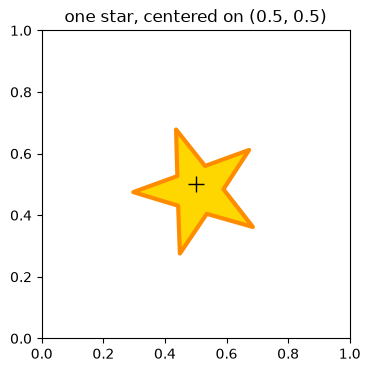

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")

svg2mpl.add_svg(STAR_SVG, xy=(0.5, 0.5), width=0.4, origin=(0.5, 0.5),
                rotation=20, ax=ax)
ax.plot(0.5, 0.5, "k+", markersize=12)  # mark the anchor
ax.set_title("one star, centered on (0.5, 0.5)")
plt.show()

## Stamping a drawing as a marker

Because each SVG source is parsed once and cached, calling `add_svg` in a loop to
place the same drawing many times is cheap. Here we scatter stars whose size and
rotation vary with the data.

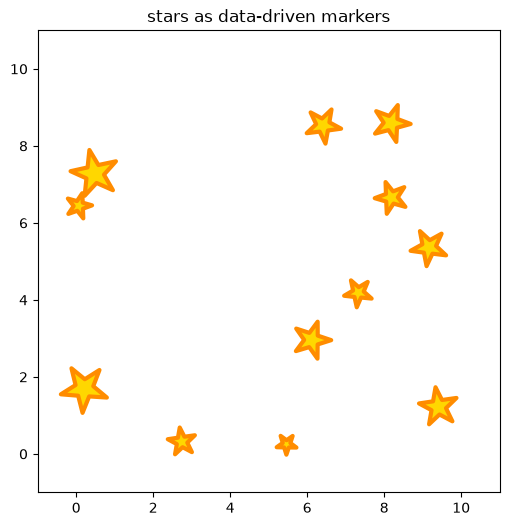

In [5]:
rng = np.random.default_rng(0)
n = 12
xs = rng.uniform(0, 10, n)
ys = rng.uniform(0, 10, n)
sizes = rng.uniform(0.4, 1.2, n)

fig, ax = plt.subplots(figsize=(6, 6))
for x, y, s in zip(xs, ys, sizes):
    svg2mpl.add_svg(
        STAR_SVG,
        xy=(x, y),
        width=s,
        rotation=rng.uniform(0, 90),
        ax=ax,
    )
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 11)
ax.set_aspect("equal")
ax.set_title("stars as data-driven markers")
plt.show()

## `place=False`: faithful absolute layout

With `place=False`, the drawing is rendered in its own coordinate system, exactly
reproducing the SVG's absolute layout (only `flip_y` still applies). Compare it
with the placed version, which has been re-centered and scaled.

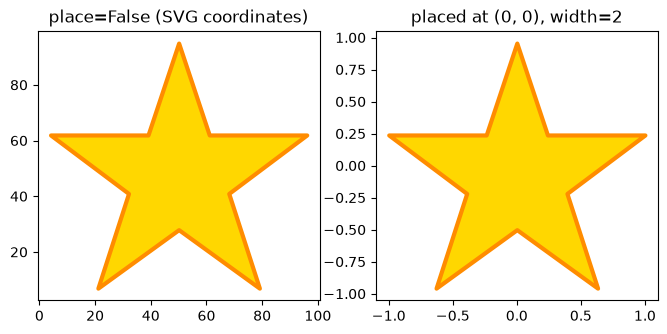

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

svg2mpl.add_svg(STAR_SVG, place=False, ax=axes[0])
axes[0].set_title("place=False (SVG coordinates)")

svg2mpl.add_svg(STAR_SVG, xy=(0, 0), width=2, ax=axes[1])
axes[1].set_title("placed at (0, 0), width=2")

for ax in axes:
    ax.set_aspect("equal")
plt.show()